In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

In [56]:
#Defining the Double Convolution step because it is needed frequently in the Unet architecture
class DoubleConv2d(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.model=nn.Sequential(nn.Conv2d(in_channels,out_channels,3,padding=1),nn.BatchNorm2d(out_channels),nn.ReLU(),
                            nn.Conv2d(out_channels,out_channels,3,padding=1),nn.BatchNorm2d(out_channels),nn.ReLU()) 
    def forward(self,x):
        return self.model(x)

In [57]:
encoder=Encoder(3)
x=torch.randn(2,3,256,256)
output=encoder(x)
for item in output:
    print(item.shape)

torch.Size([2, 1024, 16, 16])
torch.Size([2, 64, 256, 256])
torch.Size([2, 128, 128, 128])
torch.Size([2, 256, 64, 64])
torch.Size([2, 512, 32, 32])


**Experiment 5: smp UNet with pretrained ResNet34 + DiceLoss + 6 classes (no unknown)**

In [58]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=6
)

/opt/homebrew/Cellar/jupyterlab/4.6.2/libexec/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading the Dataset(Verifying the image's properties)**

In [59]:
import os
from PIL import Image

DATA_DIR = '/Users/aavarttyagi/projects/deepglobe/train'
files = os.listdir(DATA_DIR)

images = {f.replace('_sat.jpg',''): f for f in files if f.endswith('_sat.jpg')}
masks = {f.replace('_mask.png',''): f for f in files if f.endswith('_mask.png')}

clean = []
for name in images:
    if name in masks:
        try:
            Image.open(os.path.join(DATA_DIR, images[name])).verify()
            Image.open(os.path.join(DATA_DIR, masks[name])).verify()
            clean.append(name)
        except:
            print(f"Corrupted: {name}")

print(f"Clean pairs: {len(clean)}")

Clean pairs: 803


In [60]:
# 6 classes (unknown excluded — it's an ignore class per original DeepGlobe challenge)
CLASS_NAMES = ['urban', 'agriculture', 'rangeland', 'forest', 'water', 'barren']
CLASS_COLORS = np.array([
    [0,255,255], [255,255,0], [255,0,255], [0,255,0],
    [0,0,255],   [255,255,255]
])
import torchvision.transforms as T
class DeepGlobeDataset(Dataset):
    def __init__(self, root, split='train', img_size=256):
        self.root = root
        self.img_size = img_size
        df = pd.read_csv(os.path.join(root, 'metadata.csv'))
        df = df[df['split'] == split]
        df = df.dropna(subset=['mask_path'])
        self.img_paths = [os.path.join(root, p) for p in df['sat_image_path']]
        self.mask_paths = [os.path.join(root, p) for p in df['mask_path']]
        self.normalize = T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).resize((self.img_size, self.img_size))
        img = T.ToTensor()(img)
        img = self.normalize(img)

        mask = Image.open(self.mask_paths[idx]).resize((self.img_size, self.img_size), Image.NEAREST)
        mask = np.array(mask)
        class_mask = np.full(mask.shape[:2], 6, dtype=np.int64)  # default: unknown=6
        for i, color in enumerate(CLASS_COLORS):
            class_mask[np.all(mask == color, axis=-1)] = i
        class_mask[class_mask == 6] = 0  # unknown pixels → urban (safe fallback)
        mask = torch.from_numpy(class_mask)

        return img, mask

In [62]:
import pandas as pd
from torch.utils.data import random_split

ROOT = '/Users/aavarttyagi/projects/deepglobe'
full_ds = DeepGlobeDataset(ROOT, split='train')

# valid split has no masks, so we split train 80/20
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

# ============ AUGMENTATION ============
import random as rnd

class AugmentedDataset:
    def __init__(self, dataset):
        self.dataset = dataset
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        # Random horizontal flip
        if rnd.random() > 0.5:
            img = torch.flip(img, [2])
            mask = torch.flip(mask, [1])
        # Random vertical flip
        if rnd.random() > 0.5:
            img = torch.flip(img, [1])
            mask = torch.flip(mask, [0])
        # Random rotation (90, 180, 270)
        k = rnd.randint(0, 3)
        if k > 0:
            img = torch.rot90(img, k, [1, 2])
            mask = torch.rot90(mask, k, [0, 1])
        return img, mask

train_ds_aug = AugmentedDataset(train_ds)
train_dl = DataLoader(train_ds_aug, batch_size=8, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

# ============ MODEL + LOSS ============
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
# smp UNet with pretrained ResNet34 encoder, 6 classes (no unknown)
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=6
).to(device)

# DiceLoss handles class imbalance automatically — no manual weights needed
criterion = smp.losses.DiceLoss(mode='multiclass')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

def train_one_epoch(model, dl, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for imgs, masks in dl:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dl)

def validate(model, dl, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, masks in dl:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            total_loss += criterion(preds, masks).item()
    return total_loss / max(len(dl), 1)

EPOCHS = 200
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_dl, criterion, optimizer, device)
    val_loss = validate(model, val_dl, criterion, device)
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_unet.pth')
        print("  → Saved best model!")

Train: 642, Val: 161
Epoch 1/5 | Train Loss: 0.7617 | Val Loss: 0.6647
  → Saved best model!
Epoch 2/5 | Train Loss: 0.6147 | Val Loss: 0.5749
  → Saved best model!
Epoch 3/5 | Train Loss: 0.5442 | Val Loss: 0.4961
  → Saved best model!
Epoch 4/5 | Train Loss: 0.5005 | Val Loss: 0.4391
  → Saved best model!
Epoch 5/5 | Train Loss: 0.4574 | Val Loss: 0.4315
  → Saved best model!


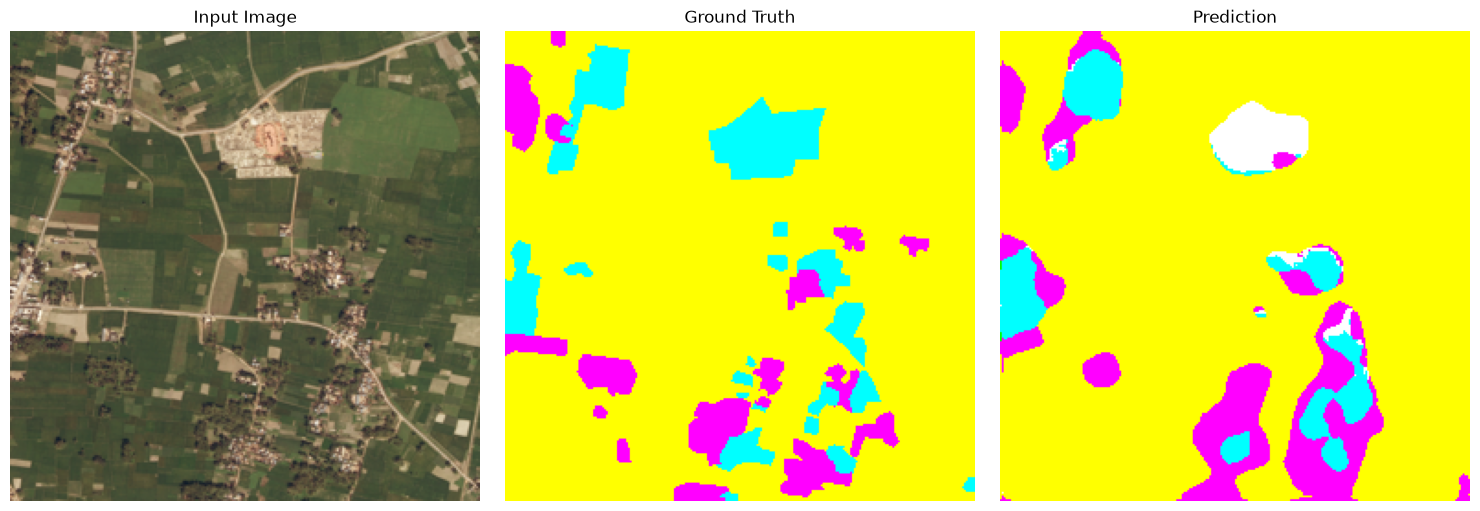

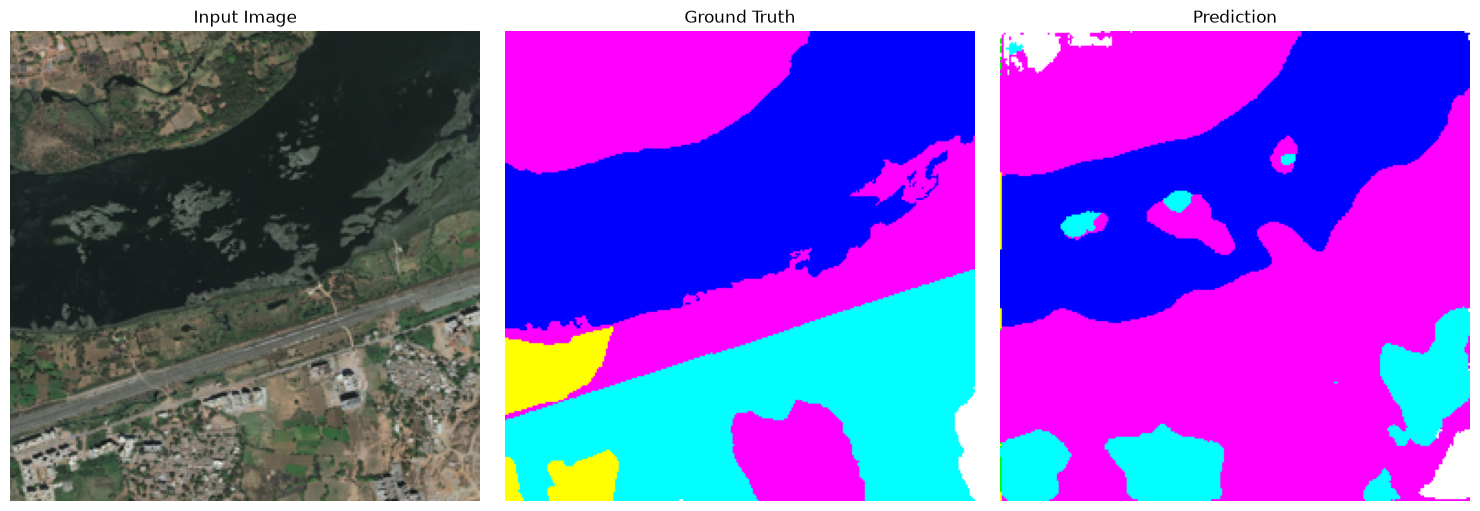

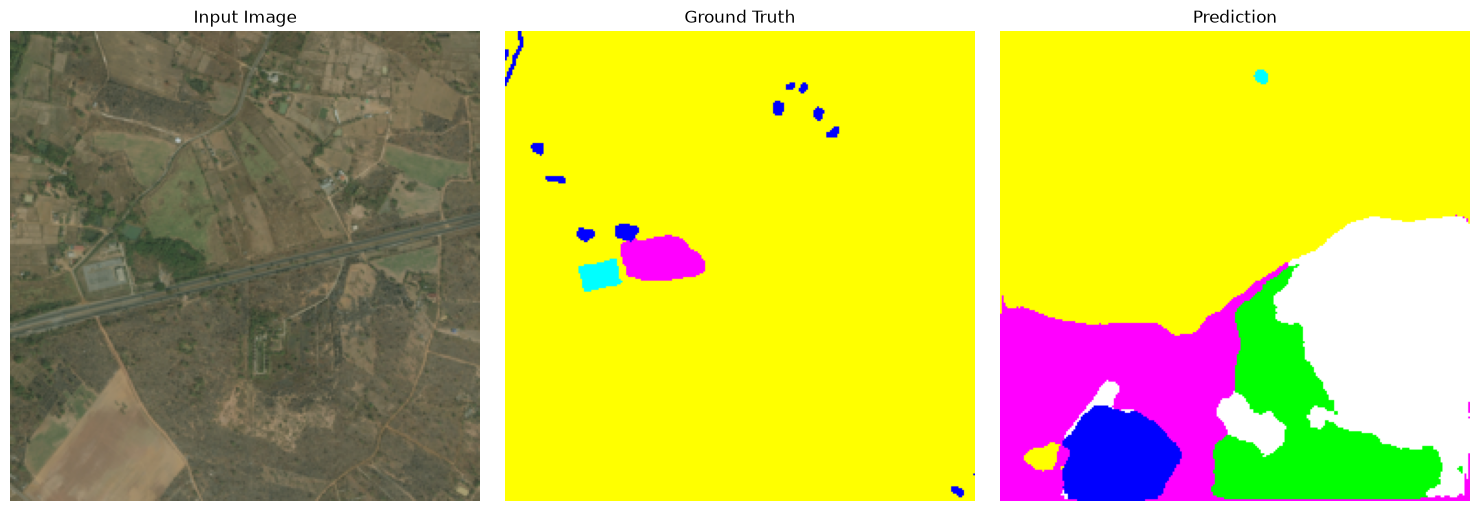

In [63]:
# ============ INFERENCE ============
CLASS_NAMES = ['urban', 'agriculture', 'rangeland', 'forest', 'water', 'barren']
CLASS_COLORS = np.array([
    [0,255,255], [255,255,0], [255,0,255], [0,255,0],
    [0,0,255],   [255,255,255]
])

# Load trained model
model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=6).to(device)
model.load_state_dict(torch.load('best_unet.pth', map_location=device))
model.eval()

def predict_and_show(idx):
    img, true_mask = val_ds[idx]
    
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred_mask = pred.argmax(dim=1).squeeze().cpu().numpy()
    
    true_mask = true_mask.numpy()
    
    def mask_to_rgb(m):
        rgb = np.zeros((m.shape[0], m.shape[1], 3), dtype=np.uint8)
        for i, color in enumerate(CLASS_COLORS):
            rgb[m == i] = color
        return rgb
    
    img_display = img.cpu().numpy().transpose(1, 2, 0)
    img_display = img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_display = np.clip(img_display, 0, 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_display)
    axes[0].set_title('Input Image')
    axes[1].imshow(mask_to_rgb(true_mask))
    axes[1].set_title('Ground Truth')
    axes[2].imshow(mask_to_rgb(pred_mask))
    axes[2].set_title('Prediction')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

import random
for i in random.sample(range(len(val_ds)), 3):
    predict_and_show(i)

In [64]:
CLASS_NAMES = ['urban', 'agriculture', 'rangeland', 'forest', 'water', 'barren']

def compute_iou_dice(pred, true, num_classes=6):
    ious = []
    dices = []
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        true_cls = (true == cls)
        intersection = (pred_cls & true_cls).sum()
        union = (pred_cls | true_cls).sum()
        iou = intersection / max(union, 1)
        dice = (2 * intersection) / max(pred_cls.sum() + true_cls.sum(), 1)
        ious.append(iou.item())
        dices.append(dice.item())
    return ious, dices

# Compute over full validation set
model.eval()
all_ious = np.zeros(6)
all_dices = np.zeros(6)

with torch.no_grad():
    for imgs, masks in val_dl:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        masks = masks.numpy()
        for j in range(imgs.size(0)):
            ious, dices = compute_iou_dice(preds[j], masks[j])
            all_ious += np.array(ious)
            all_dices += np.array(dices)

n = len(val_ds)
print(f"{'Class':<15} {'IoU':>8} {'Dice':>8}")
print("-" * 33)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<15} {all_ious[i]/n:.4f}   {all_dices[i]/n:.4f}")
print("-" * 33)
print(f"{'Mean':<15} {all_ious.mean()/n:.4f}   {all_dices.mean()/n:.4f}")

Class                IoU     Dice
---------------------------------
urban           0.2605   0.3305
agriculture     0.5089   0.5735
rangeland       0.0941   0.1403
forest          0.1684   0.2021
water           0.0924   0.1094
barren          0.1235   0.1586
---------------------------------
Mean            0.2080   0.2524


In [18]:
%pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 476.1 kB/s  0:00:01480.6 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 1.2 MB/s  0:00:031.1 MB/s eta 0:00:010m:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 2.7 MB/s  0:00:00m 2.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [segmentation-models-pytorch]5/7 [timm]ngface-hub]
Note: you may need to restart the kernel to use updated packages.
